In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes, mark_inset

import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

import numpy as np

In [35]:
def load_data(input_path: str) -> pd.DataFrame:
    df = pd.read_csv(input_path, dtype=str)
    df['max_alloc']                      = pd.to_numeric(df['max_alloc'])
    df['first']             = pd.to_numeric(df['first'])
    df['next']              = pd.to_numeric(df['next'])
    df['best']            = pd.to_numeric(df['best'])
    df['worst']            = pd.to_numeric(df['worst'])
    return df

def load_data2D(input_path: str) -> pd.DataFrame:
    df = pd.read_csv(input_path, dtype=str)
    df = df.apply(pd.to_numeric)
    return df

In [36]:
import matplotlib.ticker as mticker 

def create_plot(df):
    fig, ax = plt.subplots(dpi=100)

    df_filtered = df[["first", "next", "best", "worst"]]

    for method in df_filtered.columns:
        ax.plot(df["max_alloc"], df_filtered[method], label=method)

    ax.legend()
    ax.set_xlabel("Maximale Größe einer einzelnen Allozierung")
    ax.set_ylabel("Anzahl Allozierungen")
    ax.set_title("Vergleich Allozierungsverfahren")
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, which="both")

    plt.show()

In [37]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def create_plot_new(df):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

    methods = ["first", "next", "best", "worst"]

    df_filtered = df[["max_alloc"] + methods]
    df_filtered = df_filtered.loc[df_filtered["max_alloc"] >= 10]

    for method in methods:
        ax.plot(df_filtered["max_alloc"], df_filtered[method], label=method)

    
    ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlabel("Maximale Größe einer einzelnen Allozierung")
    ax.set_ylabel("Anzahl Allozierungen")
    ax.set_title("Vergleich Allozierungsverfahren")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, which="both")
    ax.legend()

    # Zoom-Inset: fixed size as a fraction of the parent axes (no log-scale sizing bug)
    axins = ax.inset_axes([0.35, 0.5, 0.45, 0.4])  # [x0, y0, width, height] in axes-fraction coords

    for method in methods:
        axins.plot(df_filtered["max_alloc"], df_filtered[method])

    #axins.set_xscale("log")
    #axins.set_yscale("log")
    axins.set_xlim(100, 150)
    axins.set_ylim(10000, 50000)

    mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.5")
    # or, equivalently and slightly simpler: ax.indicate_inset_zoom(axins, edgecolor="0.5")

    print(fig.get_size_inches(), fig.dpi)

    plt.show()

In [38]:
def compute_best_algo(df, methods):
    """Return the winning method per row, or 'tie' if multiple methods share the max."""
    vals = df[methods].values
    max_val = vals.max(axis=1)
    is_max = (vals == max_val[:, None])
    n_max = is_max.sum(axis=1)

    methods_arr = np.array(methods)
    idx_max = vals.argmax(axis=1)  # first max, used only when there's no tie

    best = np.where(n_max > 1, "tie", methods_arr[idx_max])
    return best

In [39]:
def plot_best_algo_grid_blend(df, x_bins=100, y_bins=100, methods=None, figsize=(8, 6)):
    if methods is None:
        methods = ["first", "next", "best", "worst"]

    df_c = df.copy()
    df_c["best_algo"] = compute_best_algo(df_c, methods)
    print(df_c["best_algo"].value_counts())

    color_map = {
        "first": np.array([31, 119, 180]) / 255,
        "next":  np.array([255, 127, 14]) / 255,
        "best":  np.array([44, 160, 44]) / 255,
        "worst": np.array([214, 39, 40]) / 255,
        "tie":   np.array([1.0, 1.0, 1.0]),
    }

    x = df_c["max_alloc"].values
    y = df_c["mem_size"].values

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    x_edges = np.linspace(xmin, xmax, x_bins + 1)
    y_edges = np.linspace(ymin, ymax, y_bins + 1)

    x_idx = np.clip(np.digitize(x, x_edges) - 1, 0, x_bins - 1)
    y_idx = np.clip(np.digitize(y, y_edges) - 1, 0, y_bins - 1)

    grid = np.ones((y_bins, x_bins, 3))  # white = empty cell (same as tie, visually)
    df_c["_xi"] = x_idx
    df_c["_yi"] = y_idx

    for (xi, yi), sub in df_c.groupby(["_xi", "_yi"]):
        fracs = sub["best_algo"].value_counts(normalize=True)
        blended = sum(color_map[algo] * frac for algo, frac in fracs.items())
        grid[yi, xi] = blended

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid, origin="lower", extent=[xmin, xmax, ymin, ymax],
              aspect="auto", interpolation="bilinear")

    ax.set_xlabel("max_alloc")
    ax.set_ylabel("mem_size")
    ax.set_title("Winning algorithm by (max_alloc, mem_size)")

    handles = [plt.Rectangle((0, 0), 1, 1, color=c)
               for algo, c in color_map.items() if algo != "tie"]
    labels = [algo for algo in color_map if algo != "tie"]
    ax.legend(handles, labels, loc="upper center",
              bbox_to_anchor=(0.5, -0.15), ncol=len(labels), frameon=False)
    plt.tight_layout()
    plt.show()

    return df_c

In [40]:
def plot_best_algo_grid(df, methods=None, figsize=(8, 8)):
    if methods is None:
        methods = ["first", "next", "best", "worst"]

    df_c = df.copy()
    df_c["best_algo"] = compute_best_algo(df_c, methods)
    print(df_c["best_algo"].value_counts())

    color_map = {
        "first": np.array([31, 119, 180]) / 255,
        "next":  np.array([255, 127, 14]) / 255,
        "best":  np.array([44, 160, 44]) / 255,
        "worst": np.array([214, 39, 40]) / 255,
        "tie":   np.array([1.0, 1.0, 1.0]),
    }

    x = df_c["max_alloc"].values
    y = df_c["mem_size"].values

    # infer step size from the actual sampled values (not bins)
    x_unique = np.sort(np.unique(x))
    y_unique = np.sort(np.unique(y))
    x_step = np.min(np.diff(x_unique)) if len(x_unique) > 1 else 1
    y_step = np.min(np.diff(y_unique)) if len(y_unique) > 1 else 1

    xmin, xmax = x_unique.min(), x_unique.max()
    ymin, ymax = y_unique.min(), y_unique.max()

    x_bins = int(round((xmax - xmin) / x_step)) + 1
    y_bins = int(round((ymax - ymin) / y_step)) + 1

    # map each row to its exact pixel (not a range-based bin)
    x_idx = np.round((x - xmin) / x_step).astype(int)
    y_idx = np.round((y - ymin) / y_step).astype(int)

    grid = np.zeros((y_bins, x_bins, 3))
    filled = np.zeros((y_bins, x_bins), dtype=bool)

    df_c["_xi"] = x_idx
    df_c["_yi"] = y_idx

    for (xi, yi), sub in df_c.groupby(["_xi", "_yi"]):
        fracs = sub["best_algo"].value_counts(normalize=True)
        blended = sum(color_map[algo] * frac for algo, frac in fracs.items())
        grid[yi, xi] = blended
        filled[yi, xi] = True

    # fill missing (unsampled) pixels from their nearest sampled neighbor
    if not filled.all():
        nearest_idx = distance_transform_edt(
            ~filled, return_distances=False, return_indices=True
        )
        grid = grid[nearest_idx[0], nearest_idx[1]]

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    ax.imshow(
        grid, origin="lower",
        extent=[xmin - x_step / 2, xmax + x_step / 2,
                ymin - y_step / 2, ymax + y_step / 2],
        aspect="auto", interpolation="nearest",
    )

    ax.set_xlabel("Maximale Größe einer einzelnen Allozierung")
    ax.set_ylabel("Verfügbarer Speicher")
    ax.set_title("Bester Algorithmus")

    handles = [plt.Rectangle((0, 0), 1, 1, color=c)
               for algo, c in color_map.items() if algo != "tie"]
    labels = [algo for algo in color_map if algo != "tie"]
    ax.legend(handles, labels, loc="upper center",
              bbox_to_anchor=(0.5, -0.15), ncol=len(labels), frameon=False)
    plt.tight_layout()
    plt.show()

    return df_c

In [41]:
def compute_best_algo_and_margin(df, methods):
    vals = df[methods].values.astype(float)

    sorted_vals = np.sort(vals, axis=1)
    top1 = sorted_vals[:, -1]
    top2 = sorted_vals[:, -2]

    # margin relative to the winner's own count, not the 4-way total
    safe_top1 = np.where(top1 == 0, 1, top1)
    margin = (top1 - top2) / safe_top1  # 0 = tie, closer to 1 = winner dominates

    max_val = vals.max(axis=1)
    is_max = (vals == max_val[:, None])
    n_max = is_max.sum(axis=1)
    methods_arr = np.array(methods)
    idx_max = vals.argmax(axis=1)
    best = np.where(n_max > 1, "tie", methods_arr[idx_max])

    return best, margin

def plot_best_algo_grid_saturation(df, methods=None, figsize=(8, 8), gamma=0.5, margin_percentile=95):
    if methods is None:
        methods = ["first", "next", "best", "worst"]

    df_c = df.copy()
    df_c["best_algo"], df_c["margin"] = compute_best_algo_and_margin(df_c, methods)
    print(df_c["best_algo"].value_counts())

    color_map = {
        "first": np.array([31, 119, 180]) / 255,
        "next":  np.array([255, 127, 14]) / 255,
        "best":  np.array([44, 160, 44]) / 255,
        "worst": np.array([214, 39, 40]) / 255,
        "tie":   np.array([1.0, 1.0, 1.0]),
    }
    white = np.array([1.0, 1.0, 1.0])

    x = df_c["max_alloc"].values
    y = df_c["mem_size"].values

    x_unique = np.sort(np.unique(x))
    y_unique = np.sort(np.unique(y))
    x_step = np.min(np.diff(x_unique)) if len(x_unique) > 1 else 1
    y_step = np.min(np.diff(y_unique)) if len(y_unique) > 1 else 1

    xmin, xmax = x_unique.min(), x_unique.max()
    ymin, ymax = y_unique.min(), y_unique.max()

    x_bins = int(round((xmax - xmin) / x_step)) + 1
    y_bins = int(round((ymax - ymin) / y_step)) + 1

    x_idx = np.round((x - xmin) / x_step).astype(int)
    y_idx = np.round((y - ymin) / y_step).astype(int)

    df_c["_xi"] = x_idx
    df_c["_yi"] = y_idx

    # normalization reference: e.g. 95th percentile of margin -> maps to full saturation
    margin_ref = np.percentile(df_c["margin"], margin_percentile)
    margin_ref = margin_ref if margin_ref > 0 else 1.0

    grid = np.ones((y_bins, x_bins, 3))
    filled = np.zeros((y_bins, x_bins), dtype=bool)

    for (xi, yi), sub in df_c.groupby(["_xi", "_yi"]):
        fracs = sub["best_algo"].value_counts(normalize=True)
        base_color = sum(color_map[algo] * frac for algo, frac in fracs.items())

        avg_margin = sub["margin"].mean()
        scaled = np.clip(avg_margin / margin_ref, 0, 1) ** gamma  # gamma < 1 boosts low-mid values

        blended = base_color * scaled + white * (1 - scaled)
        grid[yi, xi] = blended
        filled[yi, xi] = True

    if not filled.all():
        nearest_idx = distance_transform_edt(~filled, return_distances=False, return_indices=True)
        grid = grid[nearest_idx[0], nearest_idx[1]]

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    ax.imshow(grid, origin="lower",
               extent=[xmin - x_step/2, xmax + x_step/2, ymin - y_step/2, ymax + y_step/2],
               aspect="auto", interpolation="nearest")
    ax.set_xlabel("Maximale Größe einer einzelnen Allozierung")
    ax.set_ylabel("Verfügbarer Speicher")
    ax.set_title("Bester Algorithmus")

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for algo, c in color_map.items() if algo != "tie"]
    labels = [algo for algo in color_map if algo != "tie"]
    ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(labels), frameon=False)
    plt.tight_layout()
    plt.show()
    return df_c

In [42]:
def plot_speed_vs_wins(df, methods=None):
    if methods is None:
        methods = ["first", "next", "best", "worst"]

    color_map = {
        "first": "tab:blue", "next": "tab:orange",
        "best": "tab:green", "worst": "tab:red",
    }

    # total successful allocations per method, across all rows
    total_wins = df[methods].sum()

    # time_cols expected as e.g. "first_time", "next_time", ...
    avg_time_per_alloc = {
        m: df[f"{m}_time"].sum() / df[m].sum() for m in methods
    }

    fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
    for m in methods:
        ax.scatter(avg_time_per_alloc[m], total_wins[m],
                   s=120, color=color_map[m], label=m)
        ax.annotate(m, (avg_time_per_alloc[m], total_wins[m]),
                    textcoords="offset points", xytext=(6, 6))

    ax.set_xlabel("Durchschnittliche Zeit pro erfolgreiche Allozierung")
    ax.set_ylabel("Anzahl Allozierungen")
    ax.set_title("Vergleich von Zeit zu Allozierungen")
    plt.tight_layout()
    plt.show()

In [43]:
INPUT_PATH = "~/git/hsbi/BS/Praktikum2/data/benchmark_results20260707_200604.csv"
INPUT_PATH2 = "~/git/hsbi/BS/Praktikum2/data/benchmark_results_2d20260707_200544.csv"

df = load_data(INPUT_PATH)
df2D = load_data2D(INPUT_PATH2)

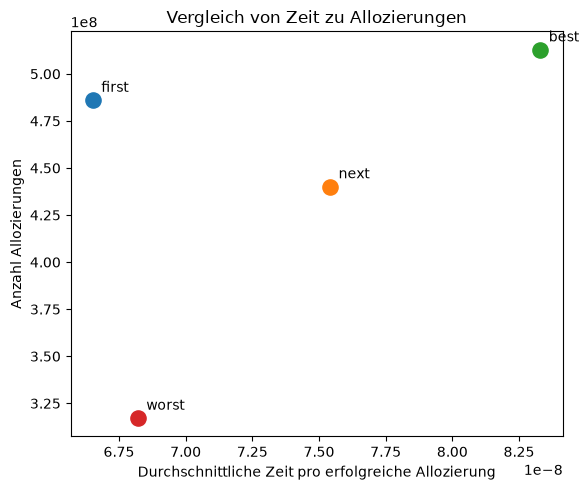

best_algo
tie      25152
best     11113
first     1659
worst      993
next       684
Name: count, dtype: int64


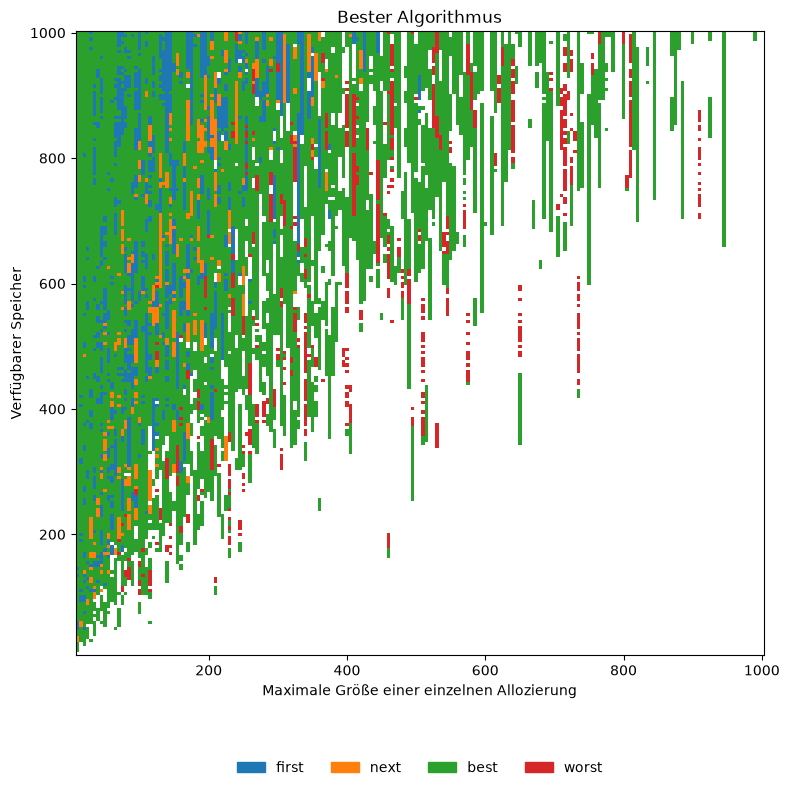

best_algo
tie      25152
best     11113
first     1659
worst      993
next       684
Name: count, dtype: int64


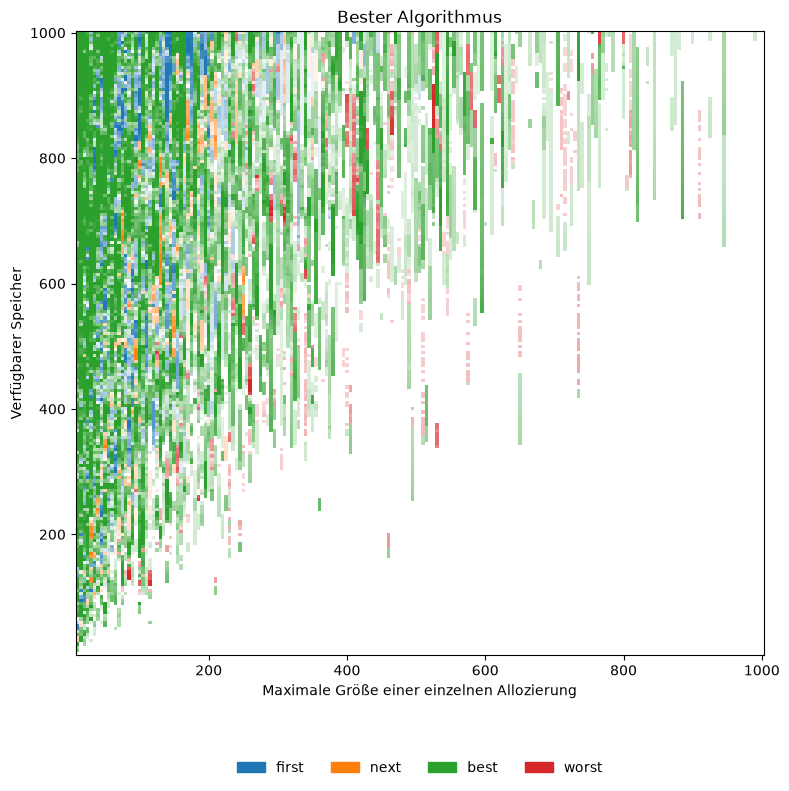

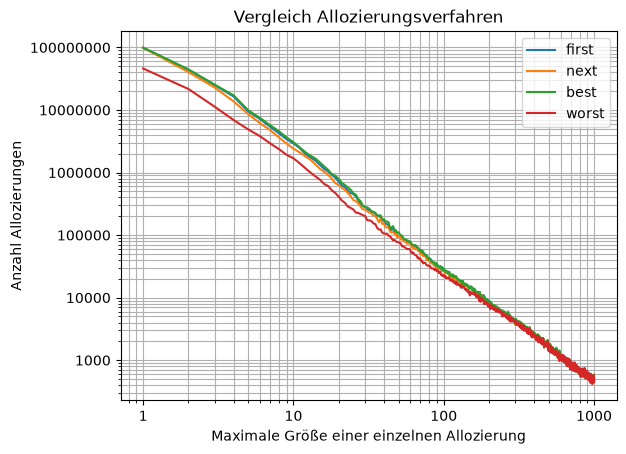

[8. 6.] 100


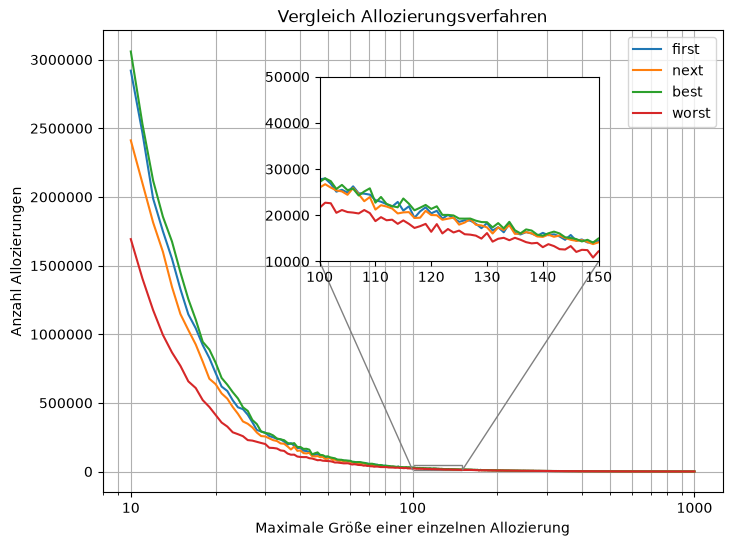

In [44]:
plot_speed_vs_wins(df2D)
plot_best_algo_grid(df2D)
plot_best_algo_grid_saturation(df2D)
create_plot(df)
create_plot_new(df)